In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, RidgeClassifier, RidgeClassifierCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, precision_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, VotingClassifier, StackingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
print(f"Dimensions des données d'entrainement: {train.shape}")
print(f"Dimensions des données d'évaluation: {test.shape}")

Dimensions des données d'entrainement: (20000, 40)
Dimensions des données d'évaluation: (63544, 39)


In [4]:
train.head()

,Num_Acc,an,int,agg,atm,col,dep,lum_1,lum_2,lum_3,...,utilisation,grave,catu_2,catu_3,conducteur_confirmé_2,conducteur_confirmé_3,catv,obsm,choc,Nb_Victimes
0,201200038712,12,0,1,1,4,790,1,0,0,...,1,1,0,0,1,0,1,0,0,1
1,201100028248,11,0,1,2,3,340,0,1,0,...,3,1,0,1,1,0,2,1,1,4
2,201200030548,12,1,1,1,3,540,0,0,1,...,1,0,0,0,1,0,2,1,1,2
3,202100010997,21,0,1,1,4,77,0,1,0,...,1,1,0,0,1,0,2,0,0,1
4,201300021489,13,1,1,1,1,280,1,0,0,...,1,0,0,0,0,1,2,2,1,4


In [5]:
test.head()

,Num_Acc,an,int,agg,atm,col,dep,lum_1,lum_2,lum_3,...,equipement,utilisation,catu_2,catu_3,conducteur_confirmé_2,conducteur_confirmé_3,catv,obsm,choc,Nb_Victimes
0,202100034563,21,1,1,1,1,72,1,0,0,...,8,1,0,0,0,0,1,2,1,4
1,202000010145,20,0,1,1,1,92,1,0,0,...,2,1,0,0,1,0,1,2,3,4
2,201800001215,18,0,1,1,3,330,1,0,0,...,1,1,0,0,0,1,2,1,1,2
3,201800033583,18,1,1,2,1,740,0,0,1,...,1,1,0,0,1,0,2,2,1,6
4,201500022329,15,0,0,1,1,50,0,1,0,...,1,1,0,0,1,0,2,2,1,10


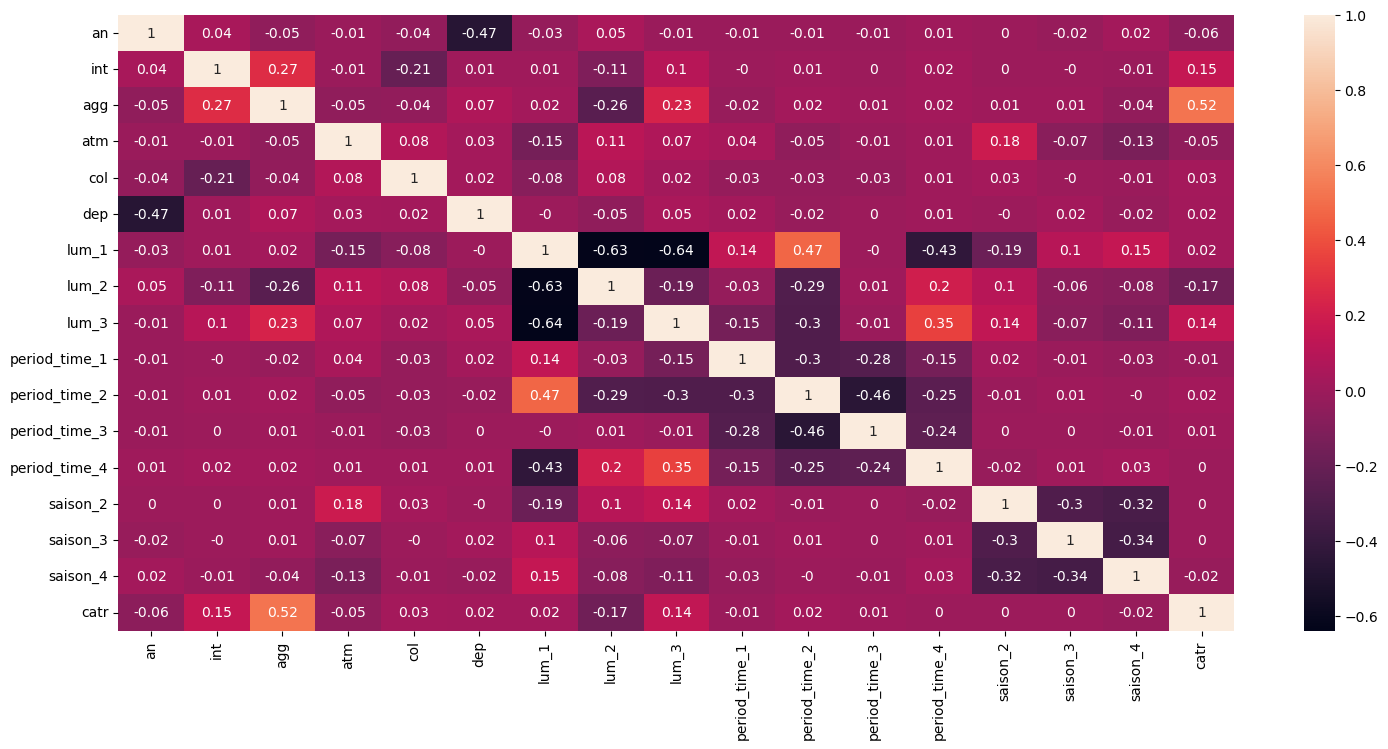

In [6]:
corr = train.iloc[:, 1:18].corr().round(2)

plt.figure(figsize=(18, 8))
sns.heatmap(corr, annot=True)
plt.show()

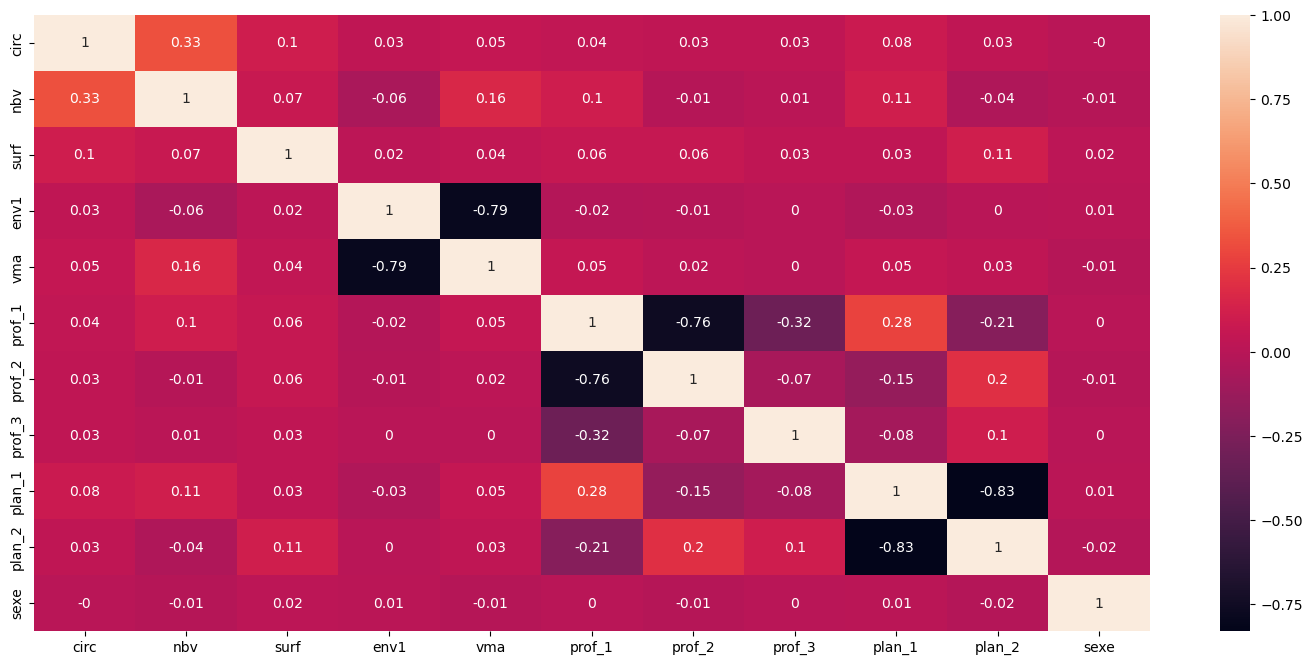

In [7]:
corr = train.iloc[:, 18:29].corr().round(2)

plt.figure(figsize=(18, 8))
sns.heatmap(corr, annot=True)
plt.show()

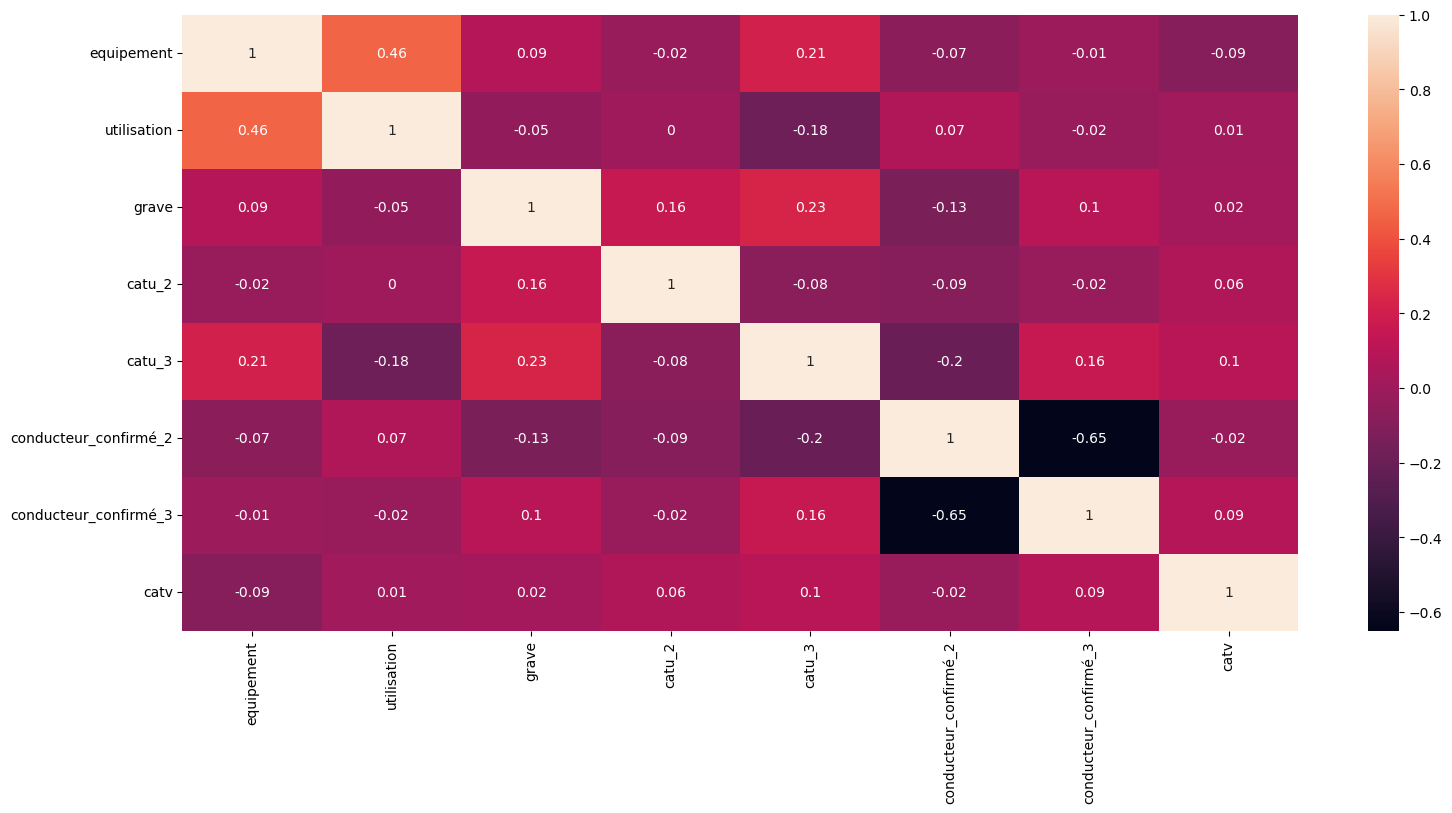

In [8]:
corr = train.iloc[:, 29:37].corr().round(2)

plt.figure(figsize=(18, 8))
sns.heatmap(corr, annot=True)
plt.show()

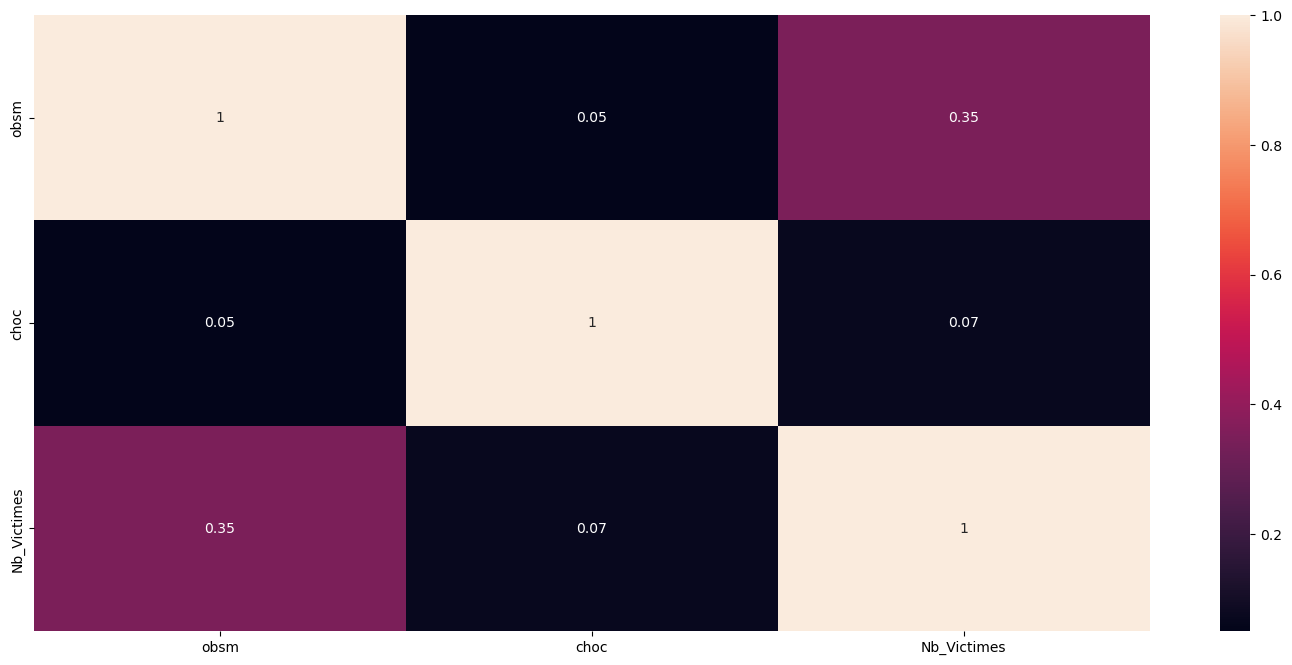

In [9]:
corr = train.iloc[:, 37:].corr().round(2)

plt.figure(figsize=(18, 8))
sns.heatmap(corr, annot=True)
plt.show()

In [10]:
y = train.loc[:, "grave"]
X = train.loc[:, ~train.columns.isin(["Num_Acc", "grave"])]

test2 = test.iloc[:, 1:]

In [11]:
print(f"Dimensions des données d'entrainement: {X.shape}, {y.shape}")
print(f"Dimensions des données d'évaluation: {test2.shape}")

Dimensions des données d'entrainement: (20000, 38), (20000,)
Dimensions des données d'évaluation: (63544, 38)


In [12]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

In [13]:
print(f"Dimensions des données d'entrainement: {X_train.shape}, {y_train.shape}")
print(f"Dimensions des données de test: {X_val.shape}, {y_val.shape}")

Dimensions des données d'entrainement: (16000, 38), (16000,)
Dimensions des données de test: (4000, 38), (4000,)


In [14]:
model = LogisticRegression(max_iter=10000)
clf = model.fit(X_train, y_train)
y_pred = clf.predict(X_val)

In [15]:
accuracy_score(y_val, y_pred)

0.72925

In [16]:
print(f"precision: {precision_score(y_val, y_pred)}")
print(f"F1 score: {f1_score(y_val, y_pred)}")
print(f"recall: {recall_score(y_val, y_pred)}")

precision: 0.6920821114369502
F1 score: 0.6354762706159542
recall: 0.5874299937772246


In [17]:
confusion_matrix(y_val, y_pred)

array([[1973,  420],
       [ 663,  944]], dtype=int64)

In [18]:
y_score = clf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_score)

0.7739899951918463

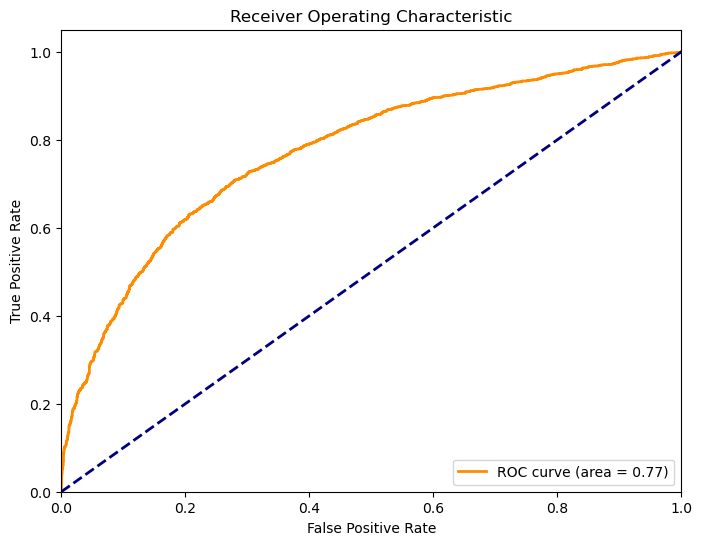

In [19]:
fpr, tpr, thresholds = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [20]:
clf = DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)

In [21]:
print(clf.get_depth())
print(clf.tree_.node_count)

28
5803


In [22]:
accuracy_score(y_val, y_pred)

0.74075

In [23]:
y_score = clf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_score)

0.7318195754002482

In [24]:
print(f"precision: {precision_score(y_val, y_pred)}")
print(f"F1 score: {f1_score(y_val, y_pred)}")
print(f"recall: {recall_score(y_val, y_pred)}")

precision: 0.6742053789731052
F1 score: 0.6802343509096516
recall: 0.686372121966397


In [25]:
ccp_alphas = clf.cost_complexity_pruning_path(X_train, y_train)["ccp_alphas"]
print(len(ccp_alphas))

1283


In [26]:
clfs = []
accuracy = []
precision = []
recall = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf = clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    clfs.append(clf)
    accuracy.append(accuracy_score(y_val, y_pred))


In [27]:
print(np.argmax(accuracy))

1203


In [28]:
print(accuracy[np.argmax(accuracy)])
clfs[np.argmax(accuracy)]

0.798


DecisionTreeClassifier(ccp_alpha=0.00028909091729806963, random_state=0)

In [29]:
clf = DecisionTreeClassifier(ccp_alpha=ccp_alphas[np.argmax(accuracy)], random_state=0)
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)
accuracy_score(y_val, y_pred)

0.798

In [30]:
print(f"precision: {precision_score(y_val, y_pred)}")
print(f"F1 score: {f1_score(y_val, y_pred)}")
print(f"recall: {recall_score(y_val, y_pred)}")

precision: 0.7795661301609517
F1 score: 0.7338603425559947
recall: 0.6932171748599876


In [31]:
y_score = clf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_score)

0.8644004461259259

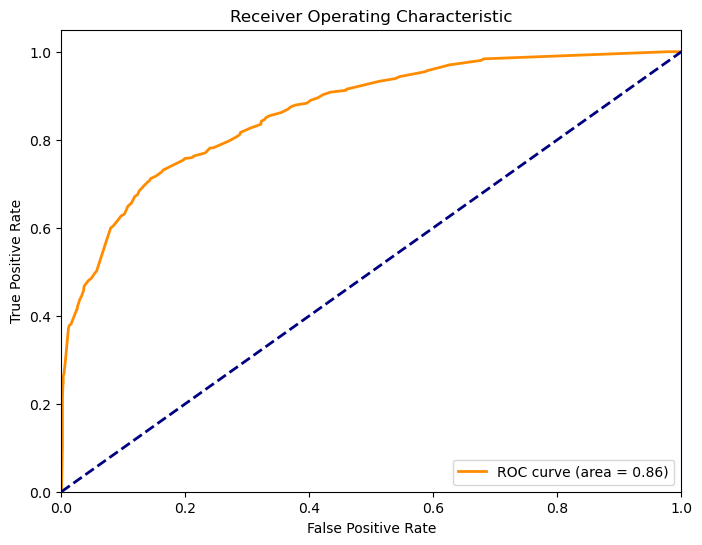

In [32]:
y_score = clf.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [38]:
params = {
    "n_estimators": [100, 150, 200],
    "criterion": ["gini", "entropy"],
    "max_features": ["sqrt", "log2", 0.4, 0.5]
}

clf = RandomForestClassifier()
grid_search = GridSearchCV(clf, params, cv=5)
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'criterion': 'entropy', 'max_features': 0.4, 'n_estimators': 200}

In [39]:
params_forest = grid_search.best_params_

In [40]:
clf = RandomForestClassifier(**params_forest)
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)
accuracy_score(y_val, y_pred)

0.80525

In [41]:
print(f"precision: {precision_score(y_val, y_pred)}")
print(f"F1 score: {f1_score(y_val, y_pred)}")
print(f"recall: {recall_score(y_val, y_pred)}")

precision: 0.7851239669421488
F1 score: 0.7453416149068323
recall: 0.7093963907902925


In [42]:
y_score = clf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_score)

0.8841296084748322

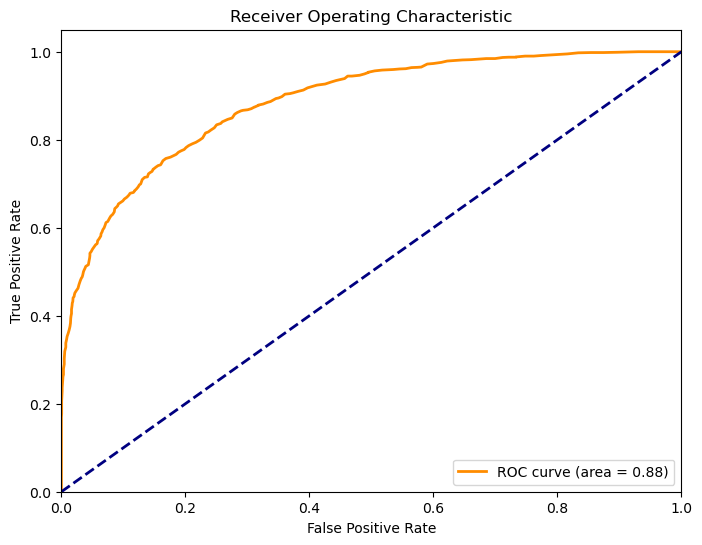

In [43]:
y_score = clf.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [44]:
parametres = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.01, 0.1],
    'max_depth': [3, 5, 7]
}

gb_clf = GradientBoostingClassifier()

grid_search = GridSearchCV(estimator=gb_clf, param_grid=parametres, cv=5)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.01, 0.01, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 150, 200]})

In [45]:
grid_search.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

In [46]:
params_boosting = grid_search.best_params_

In [47]:
clf = GradientBoostingClassifier(**params_boosting)
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)
accuracy_score(y_val, y_pred)

0.8295

In [48]:
print(f"precision: {precision_score(y_val, y_pred)}")
print(f"F1 score: {f1_score(y_val, y_pred)}")
print(f"recall: {recall_score(y_val, y_pred)}")

precision: 0.8139850644942295
F1 score: 0.7785714285714286
recall: 0.746110765401369


In [49]:
y_score = clf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_score)

0.900580176936933

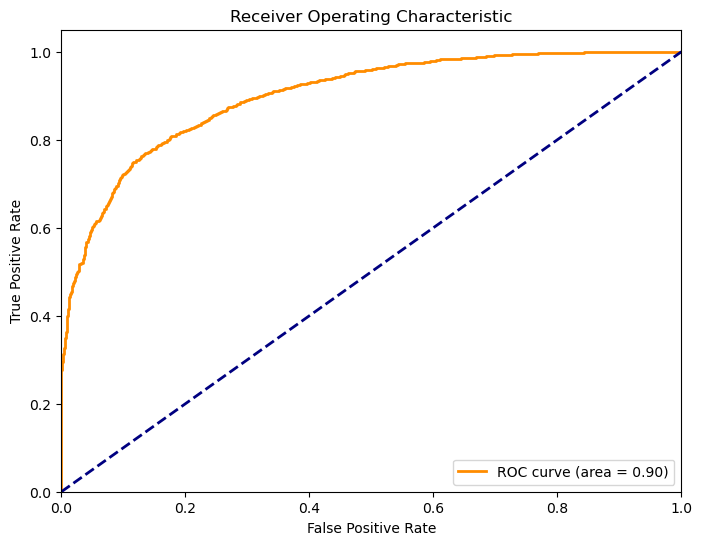

In [50]:
y_score = clf.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [51]:
ridge = RidgeClassifier(random_state=42)
lasso = Lasso(random_state=42)
elnet = ElasticNet(random_state=42)

models = (ridge, lasso, elnet)
names  = ('Ridge', 'Lasso', 'Elnet')

for clf, name in zip(models, names):
    
    # train
    clf.fit(X_train, y_train)
    
    # test
    score = clf.score(X_val, y_val)
    
    # show
    print('{:s}: {:.4f}'.format(name, score))
    
    

Ridge: 0.7290
Lasso: -0.0010
Elnet: -0.0012


In [52]:
clf = RidgeClassifier(alpha=15)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)
print(accuracy_score(y_val, y_pred))

y_score = clf.decision_function(X_val)
roc_auc_score(y_val, y_score)

0.72875


0.773430907560451

In [53]:
ridge_alphas = (1, 5, 10, 15, 30, 50)

# cross-validation strategy
cv = KFold(n_splits=5)

# models
ridge_cv = RidgeClassifierCV(alphas=ridge_alphas, cv=cv)

# train
ridge_cv.fit(X_train, y_train)

y_pred = ridge_cv.predict(X_val)
print(accuracy_score(y_val, y_pred))
print(ridge_cv.alpha_)

y_score = ridge_cv.decision_function(X_val)
roc_auc_score(y_val, y_score)

0.7295
5


0.7733513350882617

In [54]:
model = LinearSVC(C=0.1, dual="auto")

model.fit(X_train, y_train)

predictions = model.predict(X_val)

print(accuracy_score(y_val, predictions))
y_score = model.decision_function(X_val)
roc_auc_score(y_val, y_score)

0.72825


0.7734415692315613

In [55]:
model = SVC(gamma=0.1, C=2.0)     
model.fit(X_train, y_train)    
y_pred = model.predict(X_val)
print(accuracy_score(y_val, y_pred))
y_score = model.decision_function(X_val)
roc_auc_score(y_val, y_score)

0.72275


0.7832084400908998

In [59]:
# base models
models = [
    ('Logistic regression', LogisticRegression(max_iter=10000)),
    ("Linear SVC", LinearSVC(C=0.1, dual="auto")),
    ("SVC", SVC(gamma=0.1, C=2.0)),
    ("Ridge", RidgeClassifier(alpha=ridge_cv.alpha_)),
    ('Tree Classifier', DecisionTreeClassifier(ccp_alpha=ccp_alphas[np.argmax(accuracy)], random_state=0)),
    ('Random forest', RandomForestClassifier(**params_forest)),
    ('Boosting', GradientBoostingClassifier(**params_boosting))
]


In [60]:
stacking = StackingClassifier(models, final_estimator=GradientBoostingClassifier())

stacking.fit(X_train, y_train)

y_pred = stacking.predict(X_val)
    
acc = accuracy_score(y_val, y_pred)
    
y_score = stacking.predict_proba(X_val)[:, 1]
        
roc = roc_auc_score(y_val, y_score)

print('K-fold stacking: {:.4f}, {:.4f}'.format(acc, roc))

K-fold stacking: 0.8253, 0.9004


In [61]:
probas = stacking.predict_proba(test2)

probas_grave = probas[:, 1]

In [62]:
rendu = pd.DataFrame({"Num_Acc": test.iloc[:, 0], "GRAVE": probas_grave})

In [63]:
rendu.head()

,Num_Acc,GRAVE
0,202100034563,0.123191
1,202000010145,0.071386
2,201800001215,0.022761
3,201800033583,0.061655
4,201500022329,0.735112


In [64]:
rendu.shape

(63544, 2)

In [65]:
rendu.to_csv("rendu.csv", index=False)